# PI Few-Shot Prototype Evaluation

Evaluate K-shot target-domain enrollment on a trained softmax SHARP model. The checkpoint is used only as an embedding extractor; prototypes are built from a small number of target-domain enrollment windows.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("..").resolve()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DOPPLER_DIR = PROJECT_ROOT / "data" / "doppler_traces_pi"
CHECKPOINT_PATH = PROJECT_ROOT / "experiments" / "pi_classification" / "pi_all_persons_123_train_4_test_sharp_model_20260525_165437" / "model.pt"


## Load Checkpoint

In [2]:
import torch
from torch.cuda import is_available
from torch.utils.data import DataLoader

from wifi_doppler.data.dataset import DopplerWindowDataset
from wifi_doppler.models.base_model import MultiAntennaModel, SingleAntennaModel
from wifi_doppler.evaluation.fewshot import evaluate_kshot

device = "cuda" if is_available() else "cpu"
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)

config = checkpoint["config"]
PERSONS = checkpoint["labels"]
TARGET_SCENARIOS = config["test_scenarios"]
FUSION_TYPE = config.get("fusion", "mean")

model = MultiAntennaModel(SingleAntennaModel(num_classes=len(PERSONS))).to(device)

print("Checkpoint:", CHECKPOINT_PATH)
print("Target scenarios:", TARGET_SCENARIOS)
print("Labels:", PERSONS)
print("Softmax fusion:", FUSION_TYPE)
print("Device:", device)


Checkpoint: C:\Users\gianm\Development\wifi-doppler-har\experiments\pi_classification\pi_all_persons_123_train_4_test_sharp_model_20260525_165437\model.pt
Target scenarios: ['PI-4a']
Labels: ['p03', 'p05', 'p06', 'p07', 'p08', 'p09', 'p10', 'p11', 'p12', 'p13']
Softmax fusion: mean
Device: cuda


## Target-Domain Enrollment And Query Splits

Enrollment and query windows both come from the held-out target domain, but from non-overlapping temporal ranges. The model was trained on source domains only; these target windows are used only for post-hoc prototype evaluation.

In [3]:
ENROLLMENT_SPLIT = (0.0, 0.6)
QUERY_SPLIT = (0.6, 0.8)
WINDOW_SIZE = config.get("window_size", 340)
WINDOW_STRIDE = config.get("window_stride", 30)

enrollment_dataset = DopplerWindowDataset(
    DOPPLER_DIR,
    scenarios=TARGET_SCENARIOS,
    split=ENROLLMENT_SPLIT,
    window_size=WINDOW_SIZE,
    window_stride=WINDOW_STRIDE,
    labels=PERSONS,
)
query_dataset = DopplerWindowDataset(
    DOPPLER_DIR,
    scenarios=TARGET_SCENARIOS,
    split=QUERY_SPLIT,
    window_size=WINDOW_SIZE,
    window_stride=WINDOW_STRIDE,
    labels=PERSONS,
)

# Materialize LazyLinear before loading checkpoint weights.
with torch.no_grad():
    dummy = enrollment_dataset[0][0].unsqueeze(0).to(device)
    _ = model.forward_antennas(dummy)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Enrollment windows:", len(enrollment_dataset))
print("Query windows:", len(query_dataset))


Enrollment windows: 8738
Query windows: 2830


c:\Users\gianm\anaconda3\envs\wifi-doppler-har\Lib\site-packages\torch\nn\modules\conv.py:560: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\native\Convolution.cpp:1091.)
  return F.conv2d(


## Zero-Shot Softmax Baseline On Query Split

In [4]:
def evaluate_softmax_accuracy(model, dataset, device, fusion, batch_size=128):
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    correct = 0
    total = 0
    model.eval()
    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x, fusion=fusion)
            correct += (logits.argmax(dim=1) == y).sum().item()
            total += y.size(0)
    return correct / total

zero_shot_acc = evaluate_softmax_accuracy(model, query_dataset, device, FUSION_TYPE)
print(f"Zero-shot softmax accuracy on query split: {zero_shot_acc:.4f}")


Zero-shot softmax accuracy on query split: 0.3159


## K-Shot Prototype Inference

For each trial, the evaluator samples K enrollment windows per person, embeds only those selected enrollment windows, averages them into class prototypes, and classifies all precomputed query embeddings by nearest prototype.

In [5]:
K_VALUES = [1, 3, 5, 10, 25, 50, 100]
N_TRIALS = 20
EMBEDDING_FUSION = "mean"
METRIC = "cosine"

fewshot_results = evaluate_kshot(
    model,
    enrollment_dataset,
    query_dataset,
    K_VALUES,
    device=device,
    n_trials=N_TRIALS,
    seed=0,
    batch_size=128,
    embedding_fusion=EMBEDDING_FUSION,
    metric=METRIC,
)

for k, result in fewshot_results.items():
    print(f"K={k:2d}: {result['mean']:.4f} +/- {result['std']:.4f}")


K= 1: 0.2046 +/- 0.0328
K= 3: 0.2517 +/- 0.0210
K= 5: 0.2765 +/- 0.0228
K=10: 0.3044 +/- 0.0144
K=25: 0.3248 +/- 0.0184
K=50: 0.3269 +/- 0.0125
K=100: 0.3416 +/- 0.0091


## Plot Results

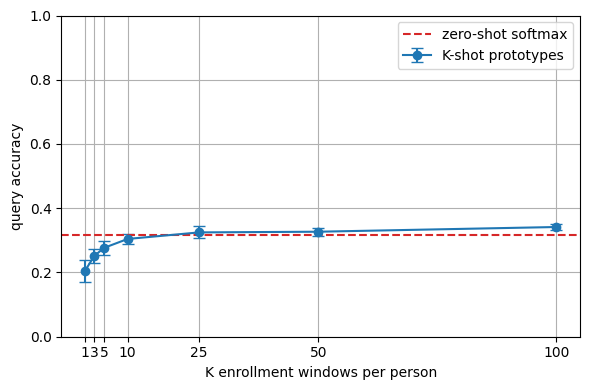

WindowsPath('C:/Users/gianm/Development/wifi-doppler-har/experiments/few_shot_softmax_evaluation/few_shot_softmax_evaluation_20260526_171738/pi_few_shot_softmax_results.json')

In [8]:
import matplotlib.pyplot as plt

from wifi_doppler.experiments.artifacts import create_run_dir, save_figure, save_json

ks = list(fewshot_results.keys())
means = [fewshot_results[k]["mean"] for k in ks]
stds = [fewshot_results[k]["std"] for k in ks]

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(ks, means, yerr=stds, marker="o", capsize=4, label="K-shot prototypes")
ax.axhline(zero_shot_acc, color="tab:red", linestyle="--", label="zero-shot softmax")
ax.set_xlabel("K enrollment windows per person")
ax.set_ylabel("query accuracy")
ax.set_ylim(0, 1)
ax.set_xticks(ks)
ax.grid(True)
ax.legend()
fig.tight_layout()
plt.show()

run_dir = create_run_dir(project_root=PROJECT_ROOT, group="few_shot_softmax_evaluation", run_name="few_shot_softmax_evaluation")
save_figure(fig, run_dir, "pi_few_shot_softmax_accuracy.png")
save_json(run_dir / "pi_few_shot_softmax_results.json", fewshot_results)